<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 3.2: Convolutional Neural Network Architecture</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **LeNet-5**

LeNet-5 (1998) was the **first CNN architecture**, designed to recognise handwritten digits. It established the foundational structure that modern CNNs still follow.

#### **Key characteristics**

- **Subsampling**: LeNet used **average pooling** to reduce the spatial resolution of feature maps
- **Activation function**: Used **Sigmoid** or **tanh** for non-linearity
- **Fully connected layers**: At the end of the network for classification
- Trained on the **MNIST digit dataset** with 60,000 training examples


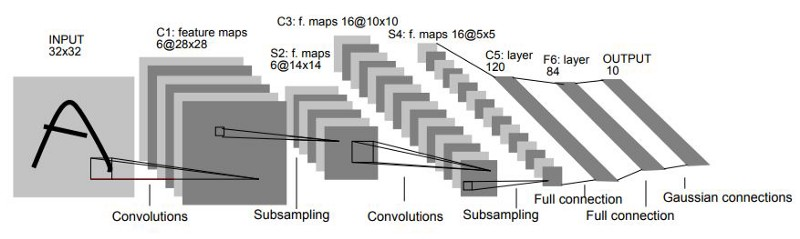

*LeNet-5 architecture (1998) adapted from LeCun et al.*

<br>

### **AlexNet**

Around 2010, the **ImageNet** dataset was released — over 14 million labelled images across 20,000 classes. It became the basis for the **ImageNet Large-Scale Visual Recognition Challenge (ILSVRC)**, a benchmark competition for the research community. In 2012, **AlexNet** won this challenge and marked the moment deep learning took over computer vision.

#### **How it differs from LeNet**

AlexNet followed a similar overall framework to LeNet but with several key improvements:

- **Max pooling** instead of average pooling
- **ReLU** activation instead of Sigmoid/tanh
- **Much larger model** — 7 hidden layers, 650K units, 60M parameters
- **GPU implementation** — achieving roughly 50× speedup over CPU
- Trained on **two GPUs for a week**
- Used **dropout regularisation** to reduce overfitting

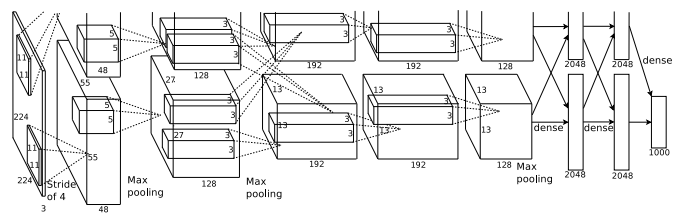

*AlexNet Model (2017) adapted from Krizhevsky et al.*

***

### **VGGNet**

VGGNet was introduced for **ILSVRC 2014**, pushing CNN architectures significantly deeper than AlexNet.

#### **Key features**

- A sequence of **progressively deeper networks** were trained and evaluated
- Large receptive fields were replaced by **successive layers of 3×3 convolutions** (with ReLU in between) — this achieves the same effective receptive field with far fewer parameters
- One $7 \times 7$ conv layer with $C$ feature maps requires $49C^2$ weights, while three $3 \times 3$ conv layers achieve the same receptive field with only $27C^2$ weights
- Experimented with **1×1 convolutions**

#### **ConvNet Configurations**

Adapted from Simonyan & Zisserman (2015). All configurations take a **224 × 224 RGB image** as input. The most commonly used variants are **VGG-16** (configuration D) and **VGG-19** (configuration E).

| Layer | A (11 layers) | A-LRN (11 layers) | B (13 layers) | C (16 layers) | D (16 layers) | E (19 layers) |
|---|---|---|---|---|---|---|
| **Conv block 1** | conv3-64 | conv3-64, LRN | conv3-64, conv3-64 | conv3-64, conv3-64 | conv3-64, conv3-64 | conv3-64, conv3-64 |
| | maxpool | maxpool | maxpool | maxpool | maxpool | maxpool |
| **Conv block 2** | conv3-128 | conv3-128 | conv3-128, conv3-128 | conv3-128, conv3-128 | conv3-128, conv3-128 | conv3-128, conv3-128 |
| | maxpool | maxpool | maxpool | maxpool | maxpool | maxpool |
| **Conv block 3** | conv3-256, conv3-256 | conv3-256, conv3-256 | conv3-256, conv3-256 | conv3-256, conv3-256, conv1-256 | conv3-256, conv3-256, conv3-256 | conv3-256, conv3-256, conv3-256, conv3-256 |
| | maxpool | maxpool | maxpool | maxpool | maxpool | maxpool |
| **Conv block 4** | conv3-512, conv3-512 | conv3-512, conv3-512 | conv3-512, conv3-512 | conv3-512, conv3-512, conv1-512 | conv3-512, conv3-512, conv3-512 | conv3-512, conv3-512, conv3-512, conv3-512 |
| | maxpool | maxpool | maxpool | maxpool | maxpool | maxpool |
| **Conv block 5** | conv3-512, conv3-512 | conv3-512, conv3-512 | conv3-512, conv3-512 | conv3-512, conv3-512, conv1-512 | conv3-512, conv3-512, conv3-512 | conv3-512, conv3-512, conv3-512, conv3-512 |
| | maxpool | maxpool | maxpool | maxpool | maxpool | maxpool |
| **FC layers** | FC-4096, FC-4096, FC-1000 | FC-4096, FC-4096, FC-1000 | FC-4096, FC-4096, FC-1000 | FC-4096, FC-4096, FC-1000 | FC-4096, FC-4096, FC-1000 | FC-4096, FC-4096, FC-1000 |
| **Output** | soft-max | soft-max | soft-max | soft-max | soft-max | soft-max |

*ConvNet configuration(2015) adapted from Simonyan & Zisserman*

#### **Number of Parameters**

Adapted from Simonyan & Zisserman (2015). Despite the increasing depth, the parameter count remains relatively similar across configurations — most parameters come from the fully connected layers, not the convolutional layers.

| Network | A, A-LRN | B | C | D | E |
|---|---|---|---|---|---|
| **Parameters (millions)** | 133 | 133 | 134 | 138 | 144 |

***

### **Network in Network (NiN) and InceptionNet**

#### **Network in Network (NiN)**

NiN (2014) introduced an interesting idea: instead of using a single linear convolution, each convolutional layer is replaced with a **multi-layer subnetwork** (essentially a small MLP applied at each spatial location).

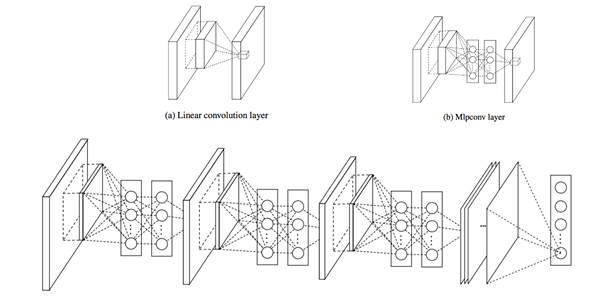

*NiN (2014) adapted from Lin et al.*

NiN also introduced **1×1 convolutions** — a convolution with a $1 \times 1$ filter that operates across the **channel dimension** rather than spatial dimensions. This allows the network to extract channel-wise features and **compress the number of channels**, reducing computational cost.

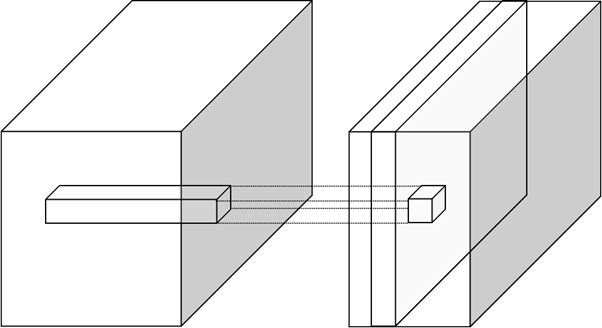

*1x1 convolutions (2022) courtesy of the Faculty of Information Technology*

#### **InceptionNet (GoogLeNet)**

InceptionNet won **ILSVRC 2014** and was published in 2015. Instead of simply stacking layers deeper, it introduced the **Inception Module**, which expands the network **horizontally**.

Key ideas:
- **Multiple parallel paths** with different filter sizes (e.g., $1 \times 1$, $3 \times 3$, $5 \times 5$) and pooling operations run simultaneously within a single module — designed to capture sparse patterns of correlations across feature maps at different scales
- **1×1 convolutions for dimensionality reduction** — applied before the more expensive $3 \times 3$ and $5 \times 5$ convolutions to reduce the number of input channels and keep computation manageable

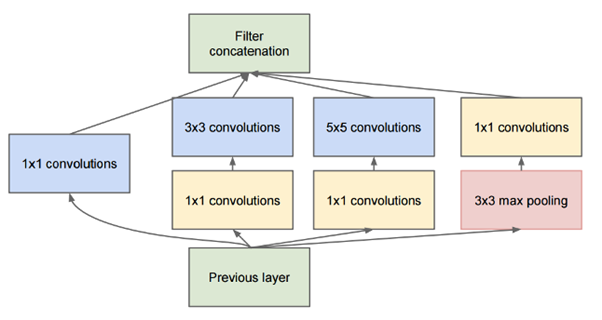

*Inception model with dimension reduction (2014) adapted from Szegedy et al.*

The full GoogLeNet architecture is built by chaining multiple Inception Modules together.

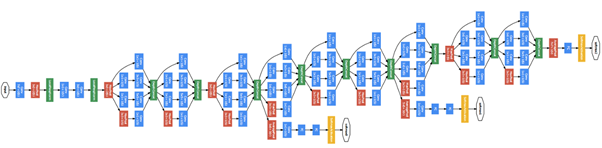

*GoogleLeNet network with bells and whistles (2014) adapted from Szegedy et al.*

#### **InceptionV2 and V3 (2016)**

The authors later introduced improved versions with several contributions:

- **Batch normalisation** to regularise training, reducing the importance of auxiliary classifiers
- More variants of Inception Modules with **aggressive factorisation of filters** (e.g., replacing a $5 \times 5$ filter with two $3 \times 3$ filters)
- **Increasing the number of feature maps while decreasing spatial resolution** through pooling

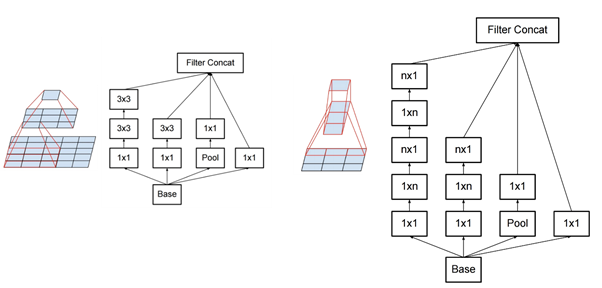

*InceptionNet structure (2015) Szegedy et al.*

***

### **ResNet**

By 2015, neural networks had grown dramatically deeper since AlexNet. The key innovation enabling this was the **residual module** introduced in ResNet.

#### **Residual Connections**

The core idea is to add **skip (shortcut) connections** that allow the input to bypass one or more layers and be added directly to the output:

$$\text{output} = F(x) + x$$

This makes it easy for layers to learn the **identity mapping** — if a layer has nothing useful to add, it can simply pass the input through unchanged. This solves the **vanishing gradient problem** that made training very deep networks difficult. Importantly, the skip connection needs to bypass **at least two layers** to be effective.

#### **Bottleneck Module**

For deeper variants, ResNet introduced a **bottleneck design** using 1×1 convolutions to compress and expand the number of channels around the $3 \times 3$ convolution. This reduces the number of parameters dramatically — from roughly **600K to 70K** per module.

#### **ResNet Configurations**

Adapted from He et al. (2016). ResNet-18 and ResNet-34 use basic blocks (two $3 \times 3$ convs), while ResNet-50, 101, and 152 use **bottleneck blocks** ($1 \times 1$, $3 \times 3$, $1 \times 1$).

| Layer Name | Output Size | 18-layer | 34-layer | 50-layer | 101-layer | 152-layer |
|---|---|---|---|---|---|---|
| **conv1_x** | 112 × 112 | | | 7 × 7, 64, stride 2 | | |
| **conv2_x** | 56 × 56 | $\begin{bmatrix} 3 \times 3, 64 \\ 3 \times 3, 64 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3 \times 3, 64 \\ 3 \times 3, 64 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1 \times 1, 64 \\ 3 \times 3, 64 \\ 1 \times 1, 256 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1 \times 1, 64 \\ 3 \times 3, 64 \\ 1 \times 1, 256 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1 \times 1, 64 \\ 3 \times 3, 64 \\ 1 \times 1, 256 \end{bmatrix} \times 3$ |
| **conv3_x** | 28 × 28 | $\begin{bmatrix} 3 \times 3, 128 \\ 3 \times 3, 128 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3 \times 3, 128 \\ 3 \times 3, 128 \end{bmatrix} \times 4$ | $\begin{bmatrix} 1 \times 1, 128 \\ 3 \times 3, 128 \\ 1 \times 1, 512 \end{bmatrix} \times 4$ | $\begin{bmatrix} 1 \times 1, 128 \\ 3 \times 3, 128 \\ 1 \times 1, 512 \end{bmatrix} \times 4$ | $\begin{bmatrix} 1 \times 1, 128 \\ 3 \times 3, 128 \\ 1 \times 1, 512 \end{bmatrix} \times 8$ |
| **conv4_x** | 14 × 14 | $\begin{bmatrix} 3 \times 3, 256 \\ 3 \times 3, 256 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3 \times 3, 256 \\ 3 \times 3, 256 \end{bmatrix} \times 6$ | $\begin{bmatrix} 1 \times 1, 256 \\ 3 \times 3, 256 \\ 1 \times 1, 1024 \end{bmatrix} \times 6$ | $\begin{bmatrix} 1 \times 1, 256 \\ 3 \times 3, 256 \\ 1 \times 1, 1024 \end{bmatrix} \times 23$ | $\begin{bmatrix} 1 \times 1, 256 \\ 3 \times 3, 256 \\ 1 \times 1, 1024 \end{bmatrix} \times 36$ |
| **conv5_x** | 7 × 7 | $\begin{bmatrix} 3 \times 3, 512 \\ 3 \times 3, 512 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3 \times 3, 512 \\ 3 \times 3, 512 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1 \times 1, 512 \\ 3 \times 3, 512 \\ 1 \times 1, 2048 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1 \times 1, 512 \\ 3 \times 3, 512 \\ 1 \times 1, 2048 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1 \times 1, 512 \\ 3 \times 3, 512 \\ 1 \times 1, 2048 \end{bmatrix} \times 3$ |
| | 1 × 1 | | | average pool, 1000-d fc, softmax | | |
| **FLOPs** | | $1.8 \times 10^9$ | $3.6 \times 10^9$ | $3.8 \times 10^9$ | $7.6 \times 10^9$ | $11.3 \times 10^9$ |

*ResNet configuration(2016) adapted from He et al.*

#### **InceptionV4**

In 2016, the authors of InceptionNet combined the ideas from both **ResNet and InceptionNet** to create **InceptionV4**. The Inception Modules were augmented with **residual connections**, making the model more powerful and easier to train at greater depth.

***

### **ResNet**

After AlexNet in 2012, neural networks grew rapidly deeper. The key innovation enabling this was the **residual module** introduced in ResNet (2015).

#### **Residual Connections**

The core ideas behind ResNet:

- Introduce **skip (shortcut) connections** that bypass one or more layers, allowing the input to be added directly to the output
- This makes it easy for layers to learn the **identity mapping** — if a layer has nothing useful to contribute, it can simply pass the input through unchanged
- The skip connection must bypass **at least two layers** to be effective

$$\text{output} = F(x) + x$$

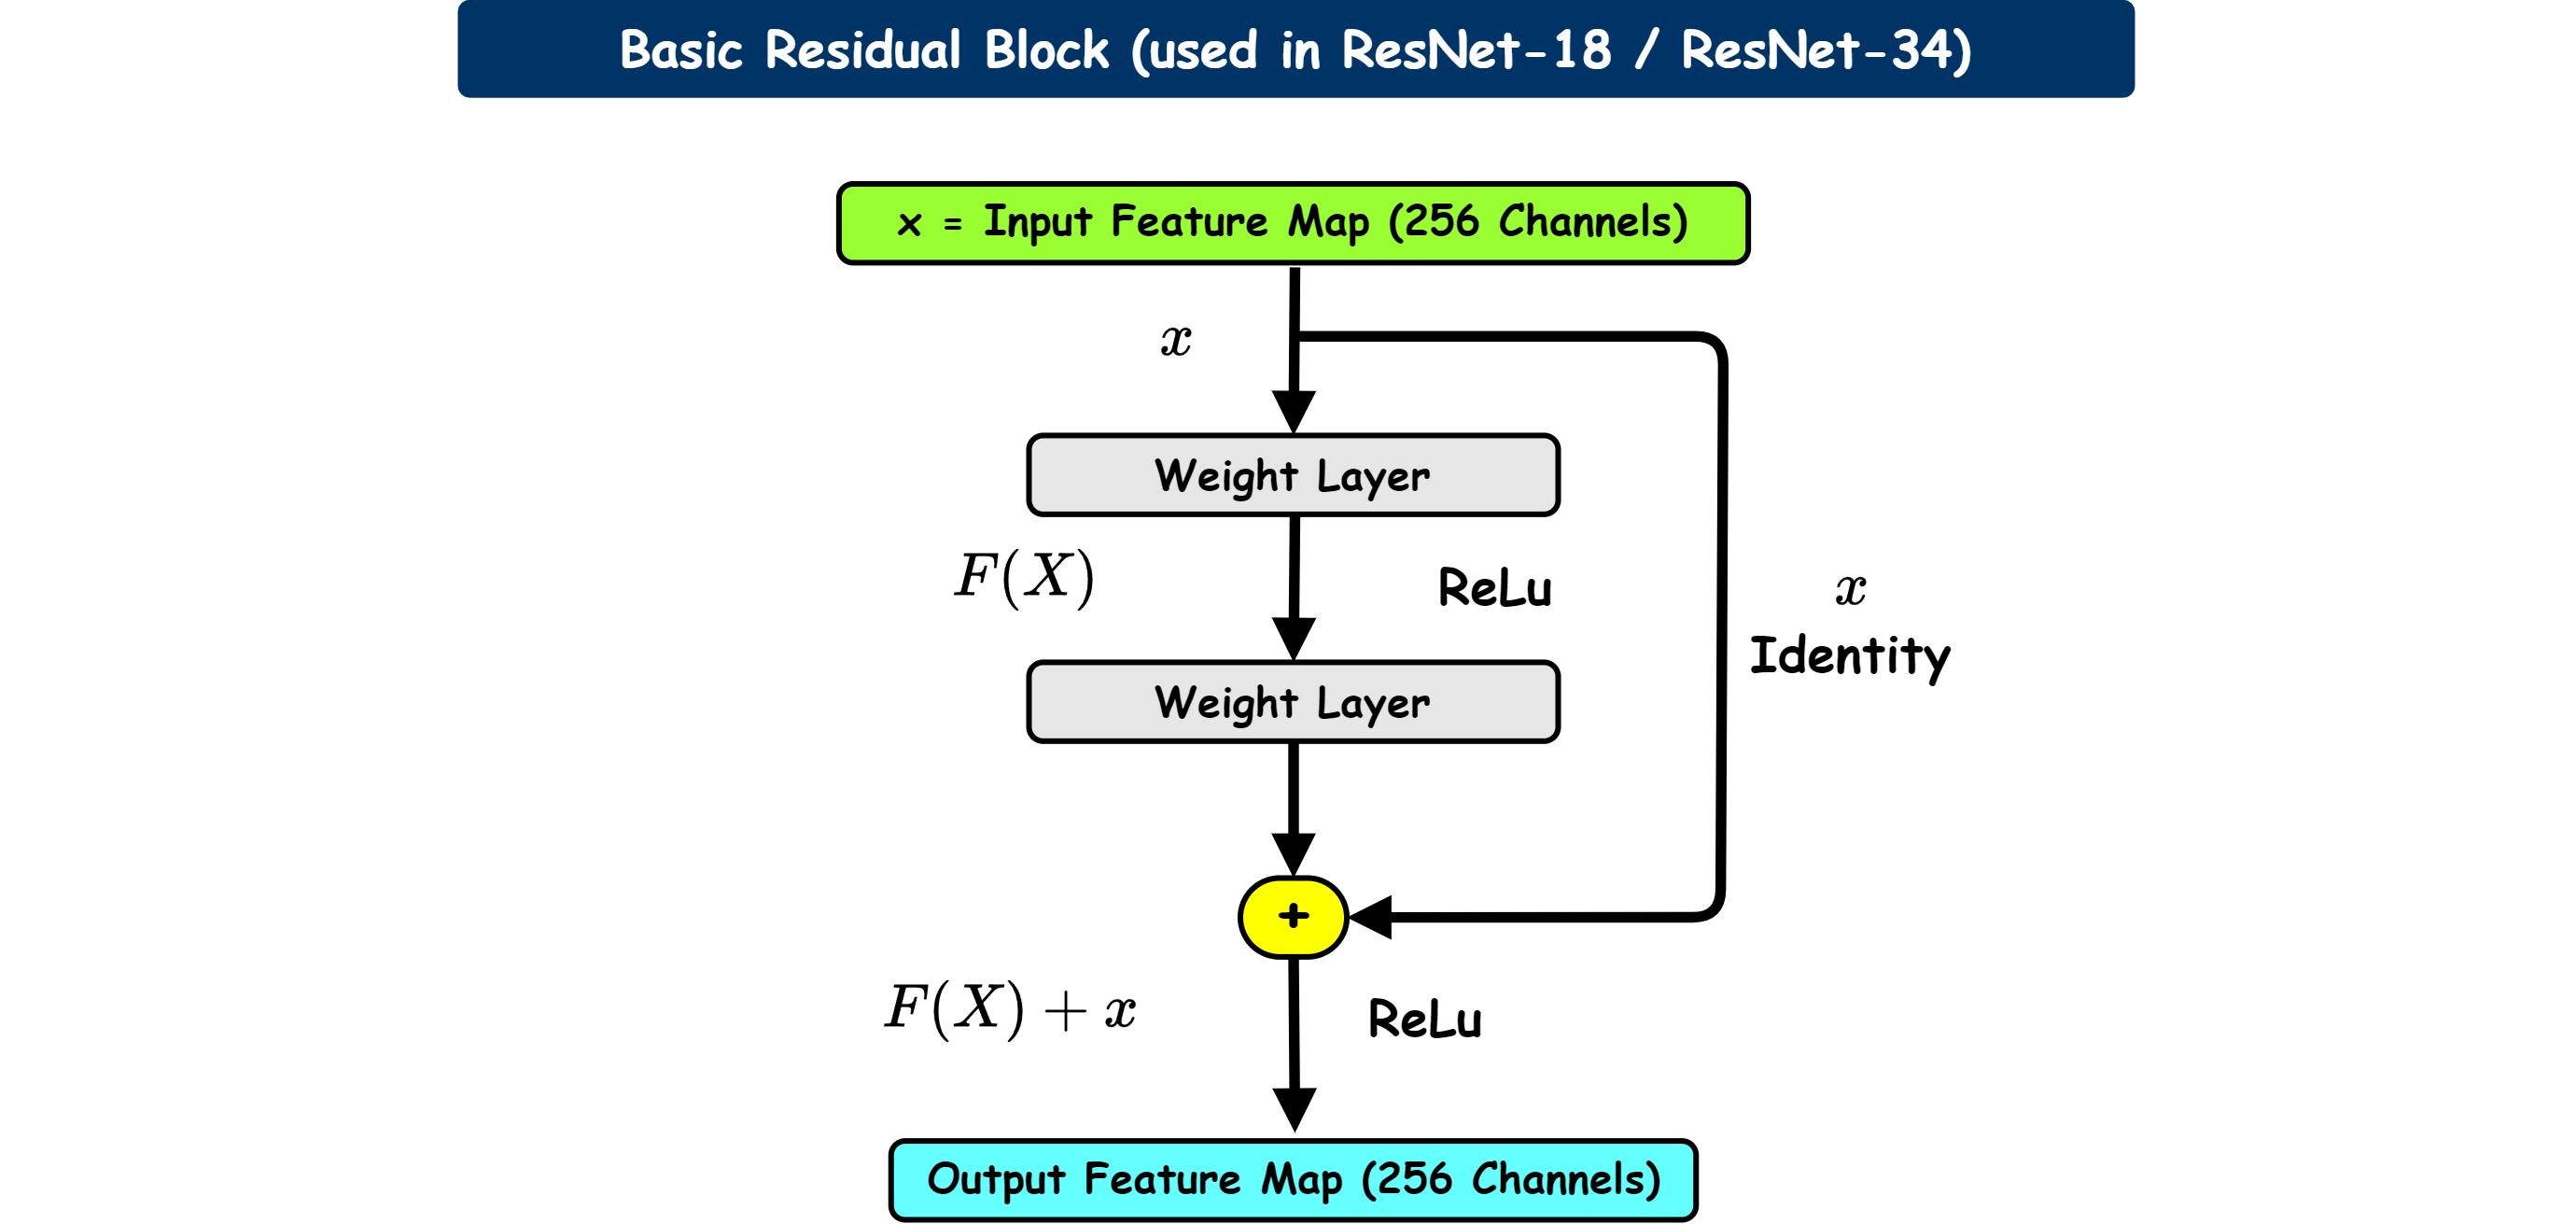

*Deep residual learning (2016) adapted from He et al.*

#### **Bottleneck Module**

ResNet also introduced a **bottleneck design** using $1 \times 1$ convolutions to compress and expand channels around the $3 \times 3$ convolution. This reduces parameters from roughly **600K to 70K** per module — nearly 9× fewer.

With these modules, ResNet scaled up to **152 layers**, a major milestone for deep learning. Several variants exist ranging from 18 to 152 layers.

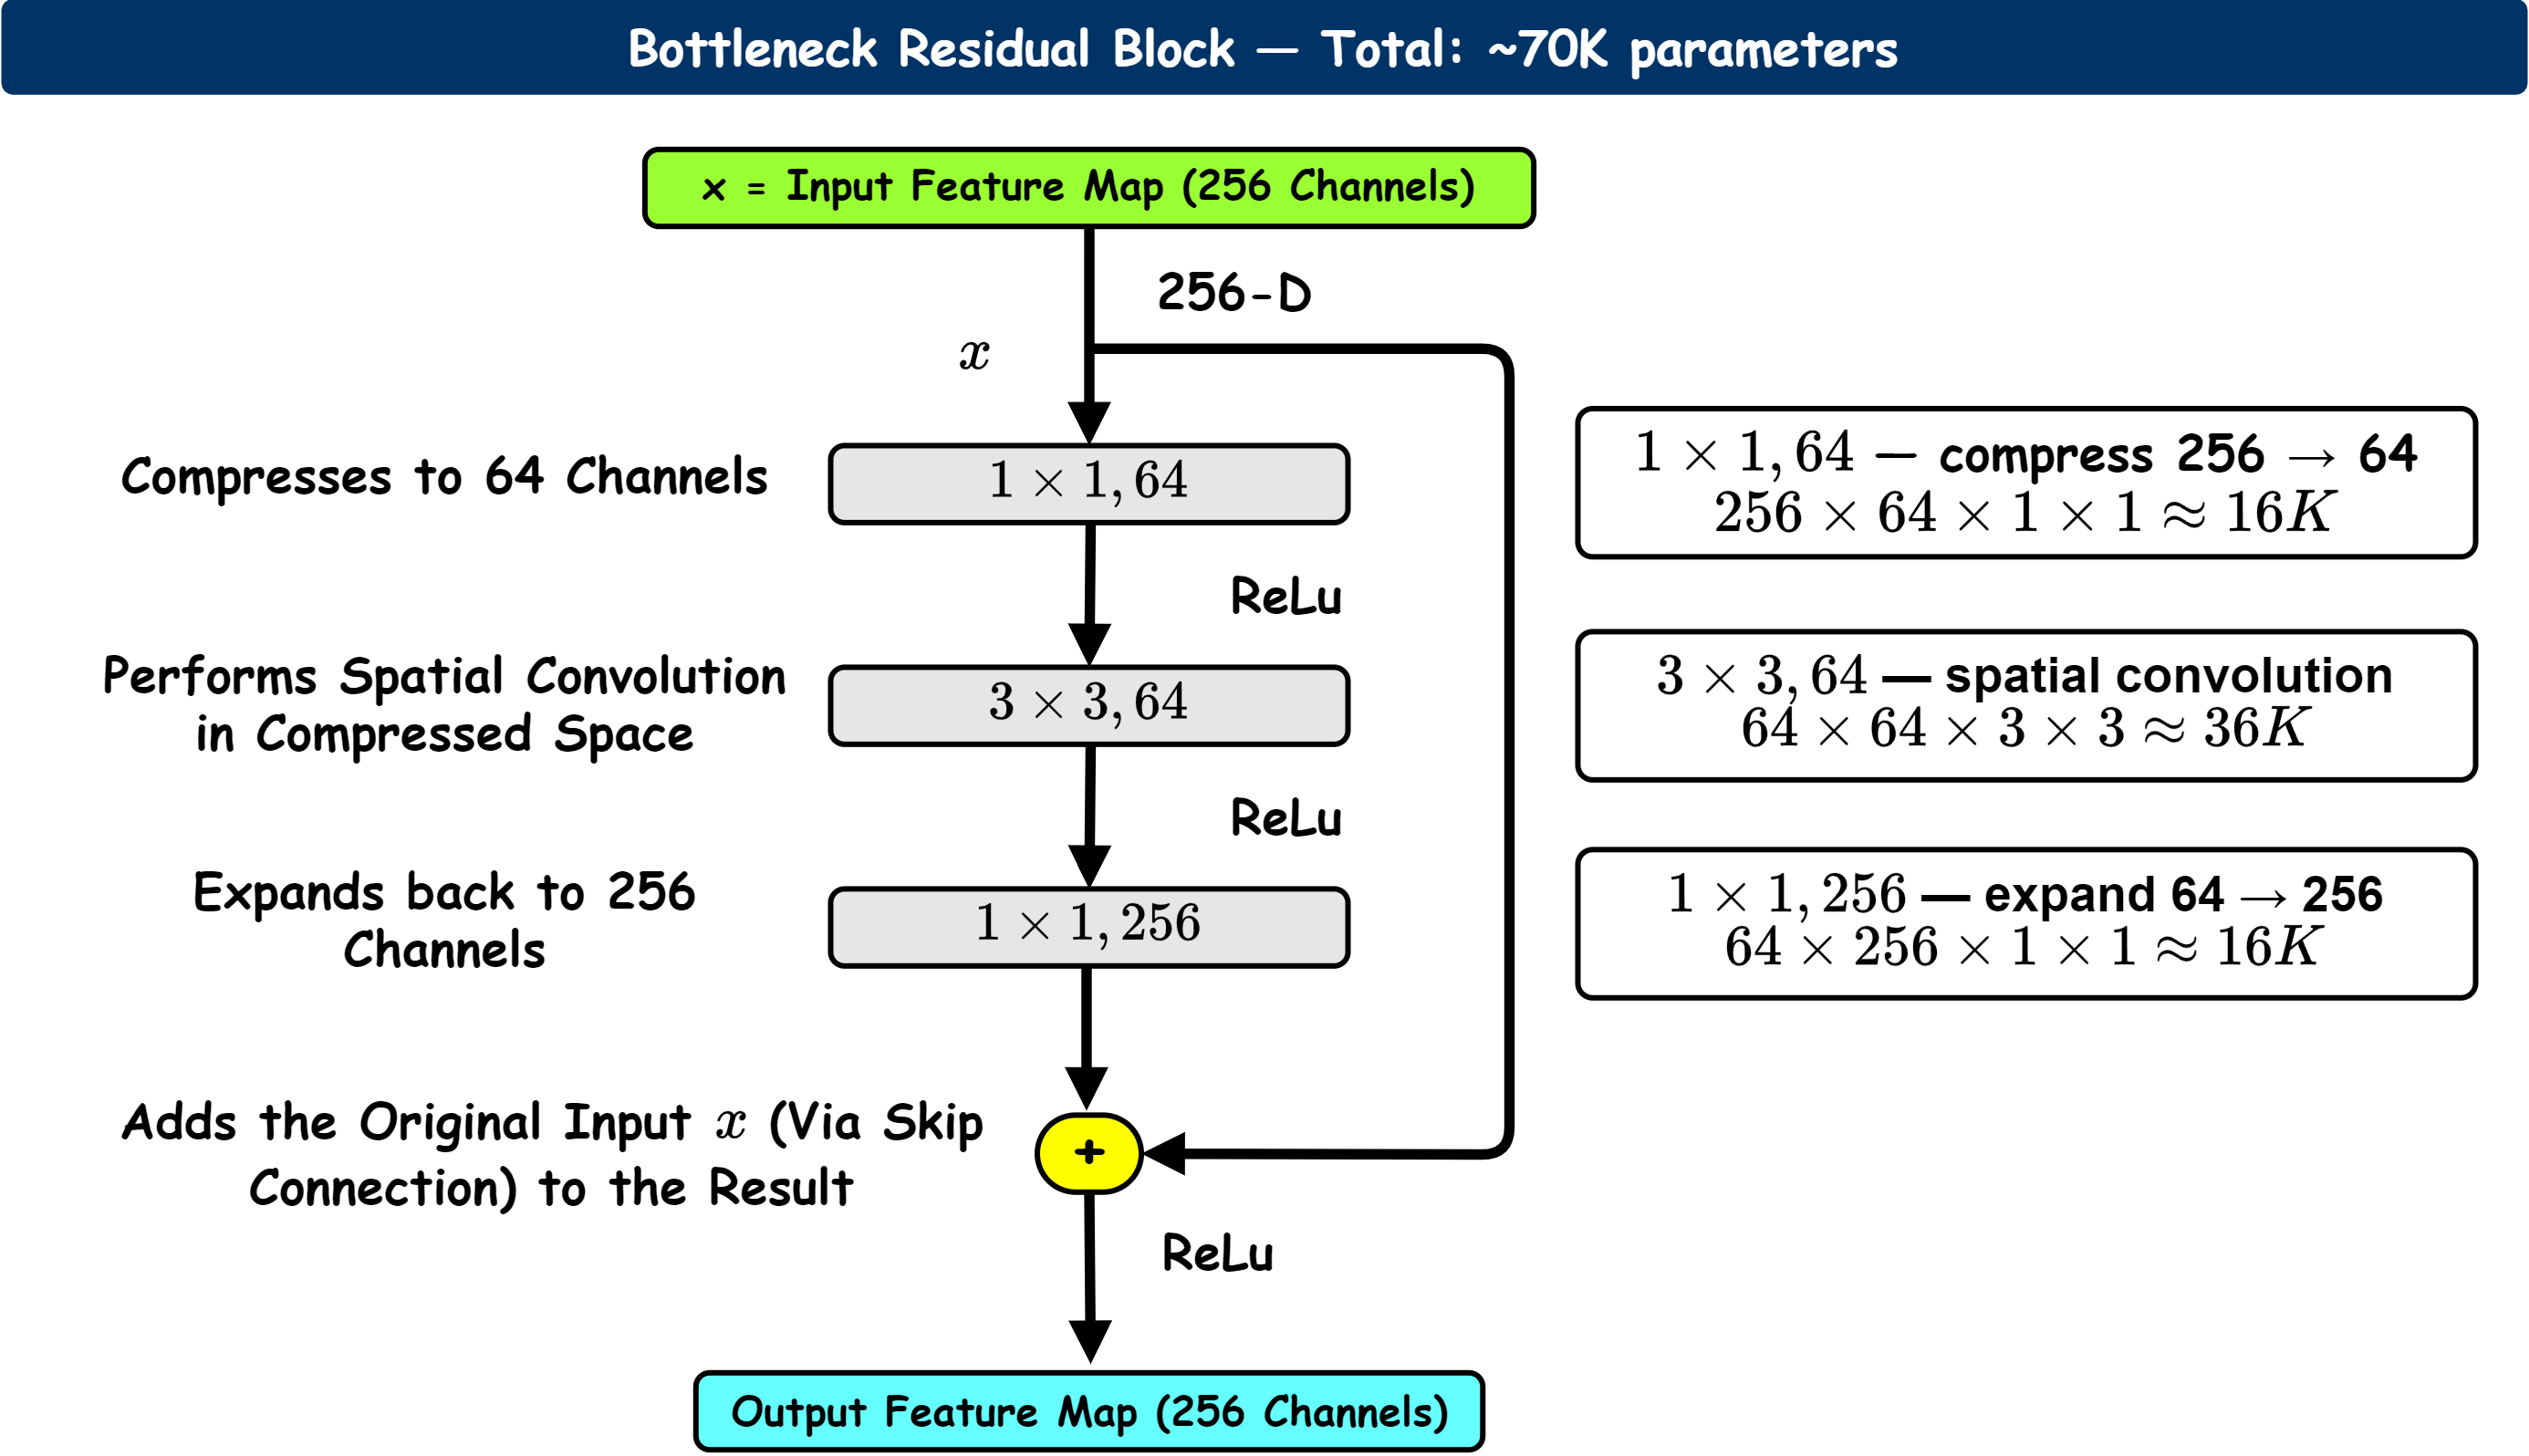

*Deeper residual module (bottleneck) (2016) adapted from He et al.*

#### **InceptionV4 (2016)**

The authors of InceptionNet combined ideas from both **ResNet and InceptionNet** to create **InceptionV4**. The Inception Modules were augmented with **residual connections**, combining multi-scale parallel processing with skip connections for a more powerful and easier-to-train architecture.

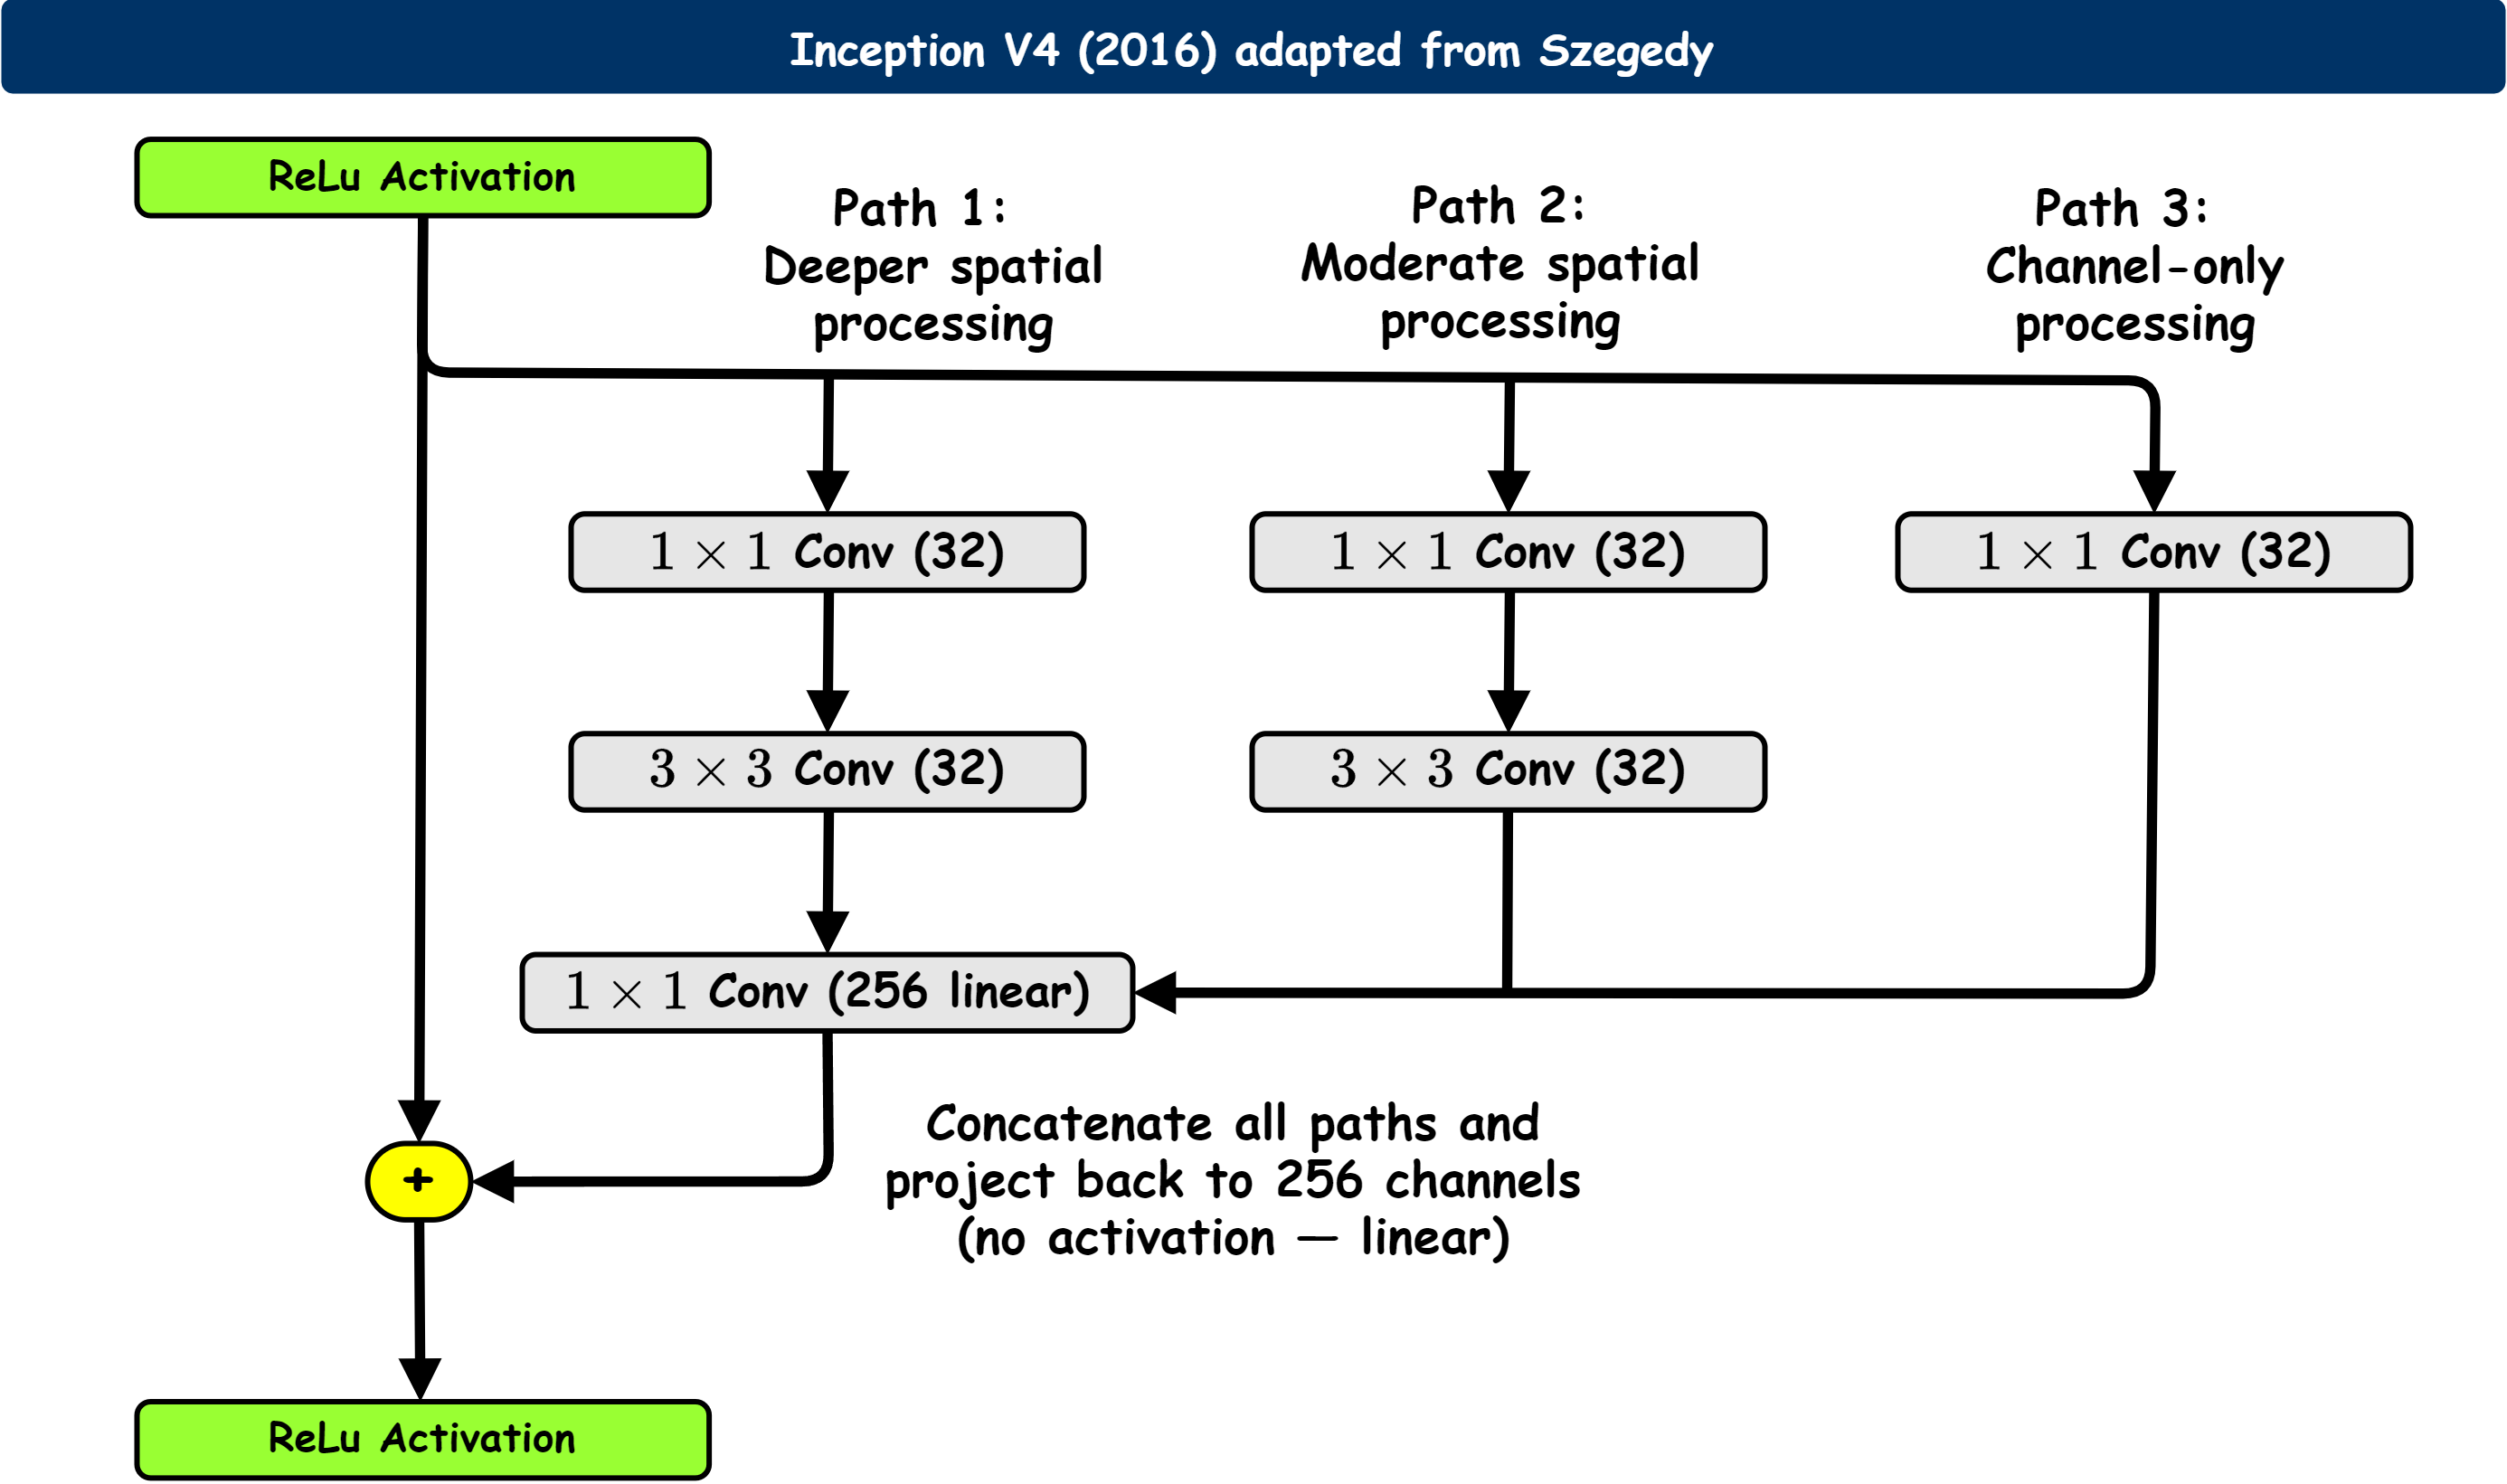

*Inception V4 (2016) adapted from Szegedy*

*** 

### **CNN Summary**

#### **Design Principles**

- **Reduce filter sizes** (except possibly at the first layer) and **factorise filters aggressively** — e.g., replace a $5 \times 5$ filter with two $3 \times 3$ filters
- Use **$1 \times 1$ convolutions** to reduce and expand the number of feature maps judiciously
- Use **skip connections** and/or create **multiple parallel paths** through the network

#### **Practical Tricks in Deep Learning**

- **Initialisation, regularisation, and normalisation** — e.g., batch normalisation, dropout, weight decay
- **Training data augmentation** — random flips, crops, rotations, and colour jittering to increase effective dataset size
- **Multi-crop/flip averaging** — averaging classifier outputs over multiple crops and flips of the same image at test time
- **Ensembles** — combining predictions from multiple independently trained networks
- **Transfer learning** — reusing a model pre-trained on a large dataset (e.g., ImageNet) and fine-tuning it for a new task

#### **Overall Trend**

CNN architectures have evolved rapidly — from LeNet (1998) to AlexNet (2012) to VGGNet, InceptionNet, and ResNet. Each generation has pushed toward **higher accuracy**, **lower computational cost**, and **fewer parameters** for image classification and beyond.